In [7]:
print("emo and sara")

emo and sara


In [1]:
import sys
!{sys.executable} -m pip install numpy


'c:\Users\sara' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import sys
print(sys.executable)

c:\Users\sara hamza\AppData\Local\Programs\Python\Python311\python.exe


In [3]:
import mne

edf_file = "Dataset/Signals/mesa-sleep-0002.edf"
raw = mne.io.read_raw_edf(edf_file, preload=False)

print("Channel names in EDF file:")
print(raw.ch_names)

Extracting EDF parameters from Dataset/Signals/mesa-sleep-0002.edf...
Setting channel info structure...
Creating raw.info structure...
Channel names in EDF file:
['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']


Extracting EDF parameters from Dataset/Signals/mesa-sleep-0010.edf...
Setting channel info structure...
Creating raw.info structure...


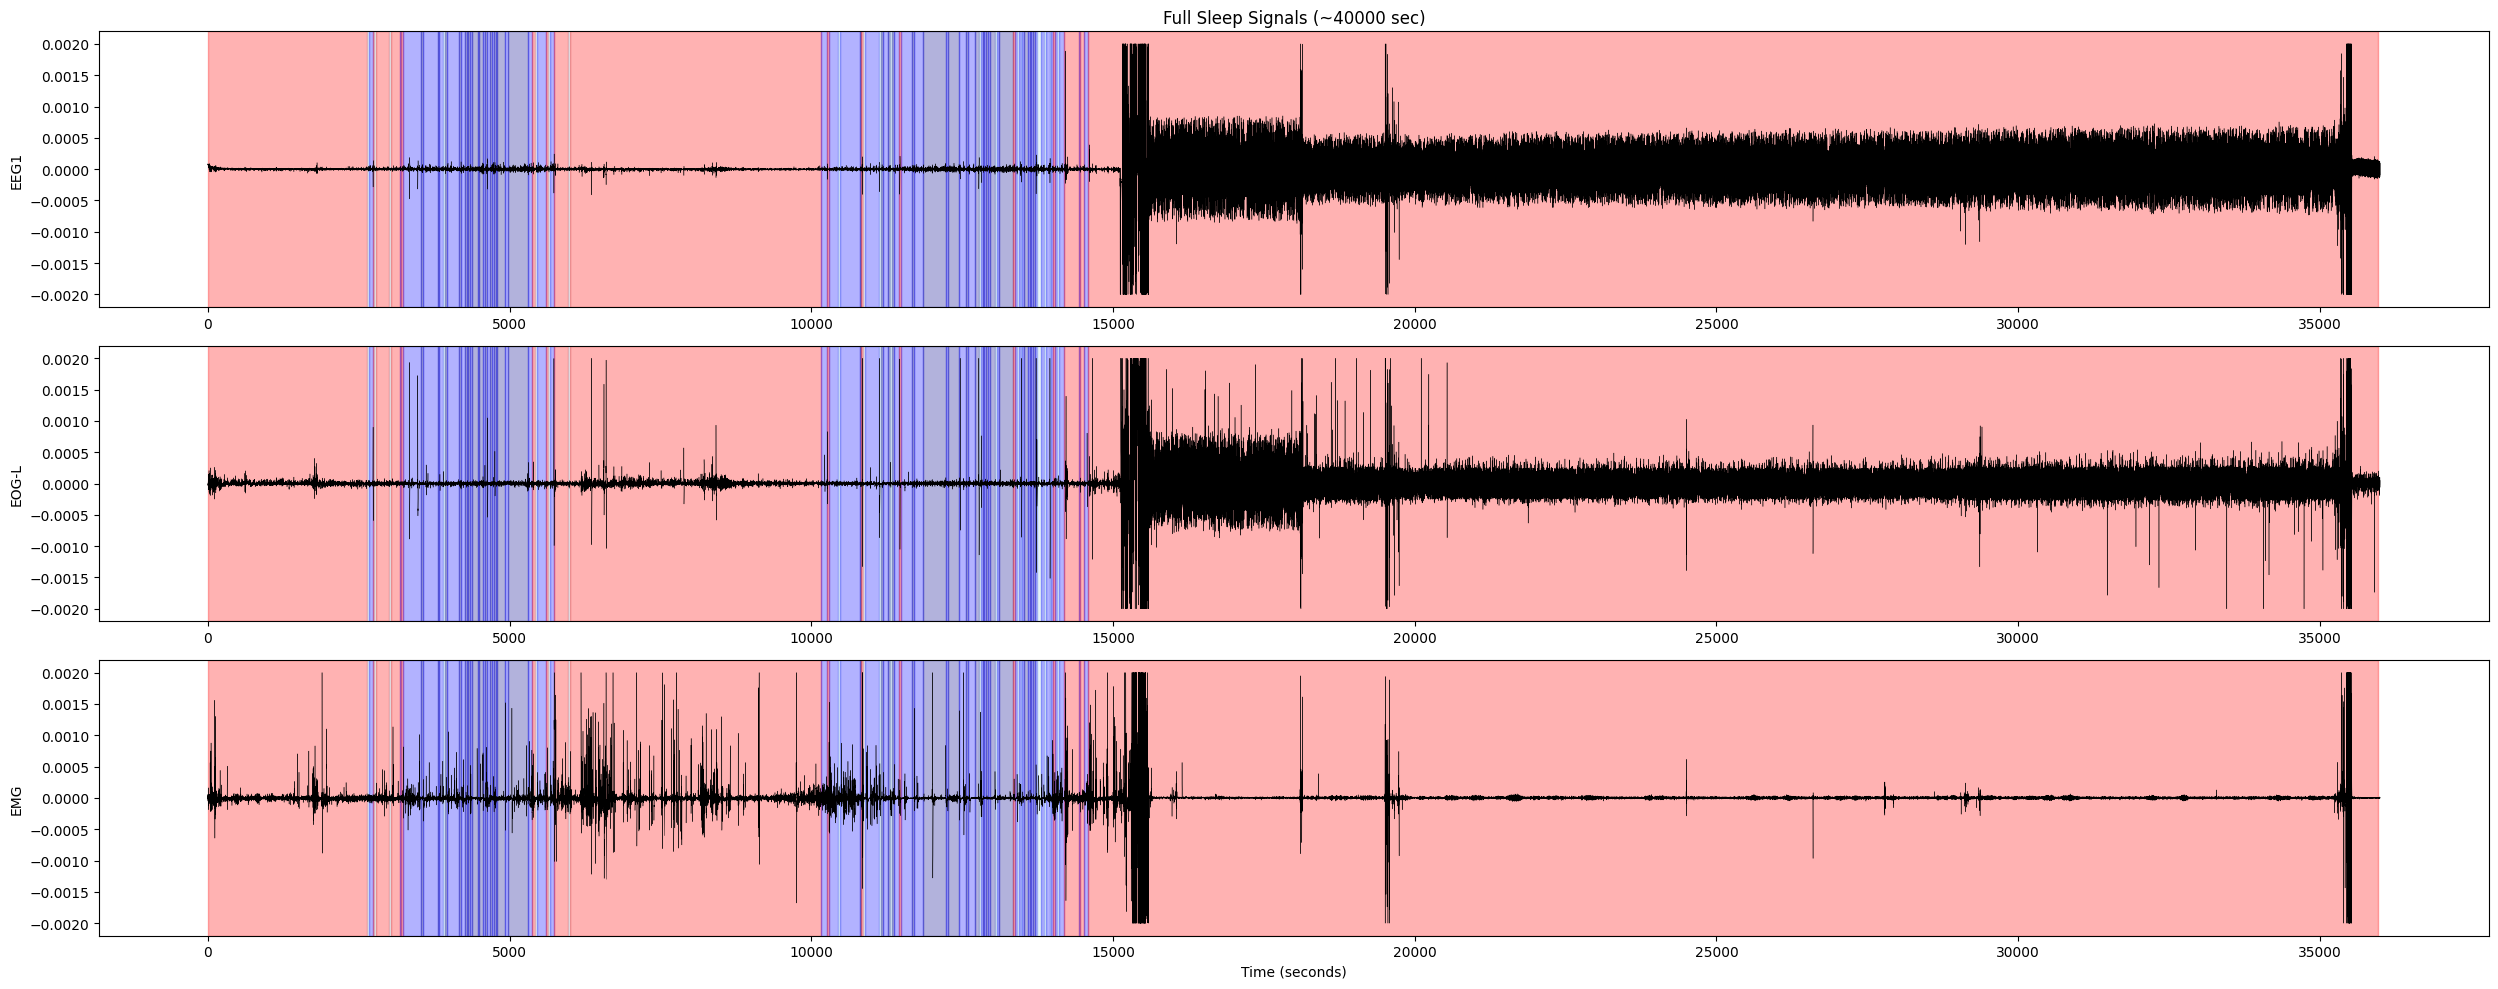

In [ ]:
import mne
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

edf_file = "Dataset/Signals/mesa-sleep-0010.edf"
xml_file = "Dataset/Annotations/mesa-sleep-0010-nsrr.xml"

channels_to_plot = ['EEG1', 'EOG-L', 'EMG']

tree = ET.parse(xml_file)
root = tree.getroot()

events = [e for e in root.findall(".//ScoredEvent")
          if e.find("EventType").text == "Stages|Stages"]

colors = {
    "Wake|0": "red",
    "Stage 1 sleep|1": "lightblue",
    "Stage 2 sleep|2": "blue",
    "Stage 3 sleep|3": "darkblue",
    "REM sleep|5": "green"
}


raw = mne.io.read_raw_edf(edf_file, preload=False)
sfreq = raw.info['sfreq']

plt.figure(figsize=(25, 10))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(len(channels_to_plot), 1, i + 1)

    data = raw.get_data(picks=ch)[0]
    times = np.arange(len(data)) / sfreq


    step = 200
    data = data[::step]
    times = times[::step]

    # رسم الإشارة
    ax.plot(times, data, color='black', linewidth=0.3)

    # رسم الـ stages
    for e in events:
        start = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage = e.find("EventConcept").text
        color = colors.get(stage, "gray")

        ax.axvspan(start, start + duration, color=color, alpha=0.3)

    ax.set_ylabel(ch)

    if i == 0:
        ax.set_title("Full Sleep Signals (~40000 sec)")

    if i == len(channels_to_plot) - 1:
        ax.set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [12]:
data split

SyntaxError: invalid syntax (3033082314.py, line 1)

In [5]:
import os
import shutil
import numpy as np

edf_dir = "Dataset/Signals"
xml_dir = "Dataset/Annotations"
files = [f.replace(".edf","") for f in os.listdir(edf_dir) if f.endswith(".edf")]
files.sort() 

In [6]:
np.random.seed(42) 
np.random.shuffle(files)

n = len(files)
train_end = int(n*0.7)
val_end = int(n*0.85)

train_files = files[:train_end]
val_files = files[train_end:val_end]
test_files = files[val_end:]

In [7]:
for split in ["train","val","test"]:
    os.makedirs(f"Dataset/{split}/Signals", exist_ok=True)
    os.makedirs(f"Dataset/{split}/Annotations", exist_ok=True)


for f in train_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/train/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/train/Annotations/")

for f in val_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/val/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/val/Annotations/")

for f in test_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/test/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/test/Annotations/")

In [ ]:
import os
import mne
import numpy as np
import xml.etree.ElementTree as ET


CHANNELS = ['EEG1', 'EOG-L', 'EMG']
TARGET_SFREQ = 100  
EPOCH_SEC = 30      
EPOCH_LENGTH = TARGET_SFREQ * EPOCH_SEC  


STAGE_MAPPING = {
    "Wake|0": 0,
    "Stage 1 sleep|1": 1,
    "Stage 2 sleep|2": 2,
    "Stage 3 sleep|3": 3,
    "REM sleep|5": 4
}

def process_single_record(edf_path, xml_path):
  
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
   
    raw.pick_channels(CHANNELS)
    
    raw.resample(TARGET_SFREQ, npad="auto", verbose=False)
    
    data = raw.get_data().T 
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    events = [e for e in root.findall(".//ScoredEvent") if e.find("EventType").text == "Stages|Stages"]
    
    num_epochs = int(data.shape[0] / EPOCH_LENGTH)
    labels = np.full(num_epochs, -1) 
    
    for e in events:
        start_time = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage_str = e.find("EventConcept").text
        
        if stage_str in STAGE_MAPPING:
            start_epoch = int(start_time / EPOCH_SEC)
            num_stage_epochs = int(duration / EPOCH_SEC)
            
            for i in range(start_epoch, min(start_epoch + num_stage_epochs, num_epochs)):
                labels[i] = STAGE_MAPPING[stage_str]
                
    data = data[:num_epochs * EPOCH_LENGTH]
    
    X = data.reshape(num_epochs, EPOCH_LENGTH, len(CHANNELS))
    y = labels
    
    valid_indices = (y != -1)
    
    return X[valid_indices], y[valid_indices]


splits = ["train", "val", "test"]

for split in splits:
    print(f"\n🚀 Processing {split.upper()} data...")
    
    signals_dir = f"Dataset/{split}/Signals"
    annotations_dir = f"Dataset/{split}/Annotations"
    save_dir = f"Dataset/Processed/{split}"
    
    os.makedirs(save_dir, exist_ok=True)
    
   
    files = [f.replace(".edf", "") for f in os.listdir(signals_dir) if f.endswith(".edf")]
    
    X_all = []
    y_all = []
    
    for f in files:
        edf_path = os.path.join(signals_dir, f + ".edf")
        xml_path = os.path.join(annotations_dir, f + "-nsrr.xml")
        
        try:
            X_subj, y_subj = process_single_record(edf_path, xml_path)
            X_all.append(X_subj)
            y_all.append(y_subj)
            print(f"✅ Processed: {f} | Shape: X={X_subj.shape}, y={y_subj.shape}")
        except Exception as e:
            print(f"❌ Error processing {f}: {e}")
            
    if X_all:
        X_split = np.vstack(X_all)
        y_split = np.concatenate(y_all)
        
        save_path = os.path.join(save_dir, f"{split}_data.npz")
        np.savez_compressed(save_path, X=X_split, y=y_split)
        print(f"🎉 Saved {split} data to {save_path} | Final Shape: X={X_split.shape}, y={y_split.shape}")


🚀 Processing TRAIN data...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0001 | Shape: X=(1439, 3000, 3), y=(1439,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0002 | Shape: X=(1319, 3000, 3), y=(1319,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0006 | Shape: X=(1079, 3000, 3), y=(1079,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0014 | Shape: X=(1679, 3000, 3), y=(1679,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0021 | Shape: X=(1079, 3000, 3), y=(1079,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0027 | Shape: X=(1199, 3000, 3), y=(1199,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processe

In [ ]:

train_data = np.load("Dataset/Processed/train/train_data.npz")
val_data   = np.load("Dataset/Processed/val/val_data.npz")
test_data  = np.load("Dataset/Processed/test/test_data.npz")

X_train, y_train = train_data['X'], train_data['y']
X_val,   y_val   = val_data['X'],   val_data['y']
X_test,  y_test  = test_data['X'],  test_data['y']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (8933, 3000, 3), y_train: (8933,)
X_val:   (1427, 3000, 3),   y_val:   (1427,)
X_test:  (2398, 3000, 3),  y_test:  (2398,)


In [ ]:
import numpy as np


class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

def analyze_distribution(y, set_name="Training"):
    unique, counts = np.unique(y, return_counts=True)
    counts_dict = dict(zip(unique, counts))
    
    print(f"\n--- {set_name} Set Distribution ---")
    total = len(y)
    for i, name in enumerate(class_names):
        count = counts_dict.get(i, 0)
        percentage = (count / total) * 100
        print(f"{name} (Class {i}): {count} samples ({percentage:.2f}%)")

analyze_distribution( y_train , "Training")
analyze_distribution( y_test , "Testing")


--- Training Set Distribution ---
Wake (Class 0): 3352 samples (37.52%)
N1 (Class 1): 765 samples (8.56%)
N2 (Class 2): 3104 samples (34.75%)
N3 (Class 3): 741 samples (8.30%)
REM (Class 4): 971 samples (10.87%)

--- Testing Set Distribution ---
Wake (Class 0): 1335 samples (55.67%)
N1 (Class 1): 92 samples (3.84%)
N2 (Class 2): 637 samples (26.56%)
N3 (Class 3): 112 samples (4.67%)
REM (Class 4): 222 samples (9.26%)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight


print("Loading processed data...")
train_data = np.load("Dataset/Processed/train/train_data.npz")
val_data = np.load("Dataset/Processed/val/val_data.npz")
test_data = np.load("Dataset/Processed/test/test_data.npz")

X_train, y_train = train_data['X'], train_data['y']
X_val, y_val = val_data['X'], val_data['y']
X_test, y_test = test_data['X'], test_data['y']

print(f"Data Loaded! Train shape: {X_train.shape}")

Loading processed data...
Data Loaded! Train shape: (8933, 3000, 3)


In [13]:
unique_classes = np.unique(y_train)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print("\n--- Calculated Class Weights ---")
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
for i, name in enumerate(class_names):
    print(f"{name}: {class_weights_dict[i]:.2f}")


--- Calculated Class Weights ---
Wake: 0.53
N1: 2.34
N2: 0.58
N3: 2.41
REM: 1.84


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import numpy as np

def se_block(x, ratio=16):
    """Recalibrates channel-wise feature responses."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(max(filters // ratio, 8), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])


def residual_conv_block(x, filters, kernel_size, strides=1):
    """Conv block with skip connection + channel attention."""
    shortcut = x

    
    out = layers.Conv1D(filters, kernel_size, strides=strides,
                        padding='same', use_bias=False)(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    out = layers.Conv1D(filters, kernel_size, strides=1,
                        padding='same', use_bias=False)(out)
    out = layers.BatchNormalization()(out)

    out = se_block(out)

    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=strides,
                                 padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add()([out, shortcut])
    out = layers.Activation('relu')(out)
    return out


def temporal_attention_block(x, num_heads=4):
    embed_dim = x.shape[-1]
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.1
    )(x, x)
    attn_out = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, attn_out]))
    
    ff = layers.Dense(embed_dim * 2, activation='gelu')(attn_out)
    ff = layers.Dense(embed_dim)(ff)
    ff = layers.Dropout(0.1)(ff)
    out = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([attn_out, ff]))
    return out

def build_improved_power_model(input_shape, num_classes=5):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(64, kernel_size=11, strides=2,
                      padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)

    x = residual_conv_block(x, filters=128, kernel_size=7)
    x = residual_conv_block(x, filters=128, kernel_size=7)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)

    x = residual_conv_block(x, filters=256, kernel_size=5)
    x = residual_conv_block(x, filters=256, kernel_size=5)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)

    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)

    x = temporal_attention_block(x, num_heads=4)

    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(256, activation='gelu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
-
    model = models.Model(inputs, outputs, name="ImprovedPowerModel")

    # ── Optimizer: AdamW with weight decay ──
    opt = optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def get_callbacks(model_path="best_model.keras"):
    return [
        # Reduce LR when validation plateaus
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-7, verbose=1
        ),
        # Save only the best checkpoint
        callbacks.ModelCheckpoint(
            model_path, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        # Stop early if no improvement
        callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1
        ),
    ]



In [ ]:

input_shape = (X_train.shape[1], X_train.shape[2])
model = build_improved_power_model(input_shape, num_classes=5)
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=None   # set dict if your classes are imbalanced
)

Model: "ImprovedPowerModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3000, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1500, 64)  │      2,112 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1500, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1500, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 750, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 750, 128)  │     57,344 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 750, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 750, 128)  │    114,688 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │      1,032 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      1,152 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 750, 128)  │      8,192 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 750, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 750, 128)  │          0 │ multiply[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 750, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                 

 Total params: 2,412,021 (9.20 MB)

 Trainable params: 2,407,541 (9.18 MB)

 Non-trainable params: 4,480 (17.50 KB)

Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5472 - loss: 1.2772
Epoch 1: val_accuracy improved from None to 0.26349, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 758s 2s/step - accuracy: 0.5981 - loss: 1.1313 - val_accuracy: 0.2635 - val_loss: 3.1352 - learning_rate: 0.0010
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6502 - loss: 0.9795
Epoch 2: val_accuracy improved from 0.26349 to 0.61808, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 801s 3s/step - accuracy: 0.6656 - loss: 0.9343 - val_accuracy: 0.6181 - val_loss: 3.1387 - learning_rate: 0.0010
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6710 - loss: 0.8647
Epoch 3: val_accuracy did not improve from 0.61808
280/280 ━━━━━━━━━━━━━━━━━━━━ 1771s 6s/step - accuracy: 0.6873 - loss: 0.8024 - val_accuracy: 0.5480 - val_loss: 1.8748 - learnin

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print("\nEvaluating on Test Data...")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

# تقرير التصنيف (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Sleep Stages')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
y_pred_val = np.argmax(model.predict(X_val), axis=1)
print(classification_report(y_val, y_pred_val, target_names=['Wake', 'N1', 'N2', 'N3', 'REM'], zero_division=0))